# 03 — Transformer Fine-tuning (BERT, RoBERTa, SciBERT)
**Project:** Syllabus Policy Stance Detection
**Author:** Charitha
**Runtime:** Google Colab — T4 GPU

## What this notebook does:
1. Fine-tunes 4 transformer models on augmented dataset
2. Fixes label encoding consistently using explicit mapping
3. Runs best variant (RoBERTa + balanced sampling + class weights)
4. Produces paper-ready comparison table and figures

## Label encoding (fixed, consistent throughout):
- discouraging = 0
- conditional  = 1
- encouraging  = 2

## Before running:
1. Runtime → Change Runtime Type → T4 GPU
2. Upload augmented_merged.csv to Google Drive
3. Update DATA_PATH in Cell 2

In [ ]:
# Cell 1 — GPU check and Drive mount
import torch
if torch.cuda.is_available():
    print(f'GPU : {torch.cuda.get_device_name(0)}')
    print(f'Mem : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('WARNING: No GPU — Runtime → Change Runtime Type → T4 GPU')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted!')

GPU : Tesla T4
Mem : 15.6 GB
Device: cuda
Mounted at /content/drive
Drive mounted!


In [ ]:
# Cell 2 — Install dependencies
!pip install transformers==4.40.0 peft==0.10.0 scikit-learn pandas numpy matplotlib seaborn -q
print('Done!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 125.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.1/199.1 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 134.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.3.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.
Done!


In [ ]:
# Cell 3 — Imports
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from peft import LoraConfig, get_peft_model, TaskType
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, accuracy_score,
    classification_report, confusion_matrix
)

print('Imports done!')
print(f'PyTorch: {torch.__version__}')

Imports done!
PyTorch: 2.10.0+cu128


In [ ]:
# Cell 4 — Paths and config
# ── UPDATE DATA_PATH to your Google Drive location ────────────────────────
DATA_PATH    = '/content/drive/MyDrive/stance_detection/augmented_merged.csv'
RESULTS_DIR  = '/content/drive/MyDrive/stance_detection/results/'
MODELS_DIR   = '/content/drive/MyDrive/stance_detection/models/'
ANALYSIS_DIR = '/content/drive/MyDrive/stance_detection/analysis/'

for d in [RESULTS_DIR, MODELS_DIR, ANALYSIS_DIR]:
    os.makedirs(d, exist_ok=True)

RANDOM_SEED   = 42
NUM_LABELS    = 3
MAX_LEN       = 128
BATCH_SIZE    = 16
EPOCHS        = 10
PATIENCE      = 3
WEIGHT_DECAY  = 0.01

# ── FIXED label mapping — explicit, never relies on LabelEncoder sorting ──
# LabelEncoder sorts alphabetically which caused bugs in original run.
# We define the mapping manually and use it everywhere.
LABEL2IDX = {'discouraging': 0, 'conditional': 1, 'encouraging': 2}
IDX2LABEL = {0: 'discouraging', 1: 'conditional', 2: 'encouraging'}
LABELS    = ['discouraging', 'conditional', 'encouraging']  # display order

print('Config set!')
print('Label mapping (fixed):')
for cls, idx in LABEL2IDX.items():
    print(f'  {idx} = {cls}')

Config set!
Label mapping (fixed):
  0 = discouraging
  1 = conditional
  2 = encouraging


In [ ]:
# Cell 5 — Load data and create train/test split
df = pd.read_csv(DATA_PATH)
print(f'Loaded: {len(df)} sentences')

# Apply fixed label mapping — no LabelEncoder
df['label'] = df['stance'].map(LABEL2IDX)

# Verify
print('\nLabel distribution:')
for cls, idx in LABEL2IDX.items():
    n = (df['label'] == idx).sum()
    print(f'  {idx} = {cls:<15}: {n}')

# Separate real and synthetic
df_real      = df[df['source'] == 'real'].reset_index(drop=True)
df_synthetic = df[df['source'] == 'synthetic'].reset_index(drop=True)
print(f'\nReal: {len(df_real)} | Synthetic: {len(df_synthetic)}')

# Split real data into train/test (stratified)
real_train, real_test = train_test_split(
    df_real, test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=df_real['stance']
)

# Add synthetic to training ONLY — never in test set
train_df = pd.concat([real_train, df_synthetic], ignore_index=True)
train_df = train_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
test_df  = real_test.reset_index(drop=True)

print(f'\nTrain: {len(train_df)} | Test: {len(test_df)}')
print('\nTrain class distribution:')
for cls, idx in LABEL2IDX.items():
    n = (train_df['label'] == idx).sum()
    print(f'  {cls:<15}: {n}')
print('\nTest class distribution (real only):')
for cls, idx in LABEL2IDX.items():
    n = (test_df['label'] == idx).sum()
    print(f'  {cls:<15}: {n}')

X_test = test_df['sentence'].values
y_test = test_df['label'].values

Loaded: 483 sentences

Label distribution:
  0 = discouraging   : 292
  1 = conditional    : 102
  2 = encouraging    : 89

Real: 354 | Synthetic: 129

Train: 412 | Test: 71

Train class distribution:
  discouraging   : 234
  conditional    : 95
  encouraging    : 83

Test class distribution (real only):
  discouraging   : 58
  conditional    : 7
  encouraging    : 6


In [ ]:
# Cell 6 — Compute class weights using FIXED label mapping
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),  # 0=disc, 1=cond, 2=enc
    y=train_df['label'].values
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

print('Class weights (balanced):')
for idx, cls in IDX2LABEL.items():
    n = (train_df['label'] == idx).sum()
    print(f'  {idx} ({cls:<15}): weight={class_weights[idx]:.3f}  (n={n})')
print()
print('Variant C weights (strong — used for best model):')
# Variant C: disc x1.5, cond x1.0, enc x2.0
total = len(train_df)
train_counts = train_df['label'].value_counts().sort_index()
strong_weights_list = []
multipliers = {0: 1.5, 1: 1.0, 2: 2.0}  # disc, cond, enc
for idx in range(3):
    w = (total / (3 * train_counts[idx])) * multipliers[idx]
    strong_weights_list.append(w)
strong_weights_tensor = torch.tensor(strong_weights_list, dtype=torch.float).to(DEVICE)
for idx, cls in IDX2LABEL.items():
    print(f'  {idx} ({cls:<15}): weight={strong_weights_list[idx]:.3f}')

Class weights (balanced):
  0 (discouraging   ): weight=0.587  (n=234)
  1 (conditional    ): weight=1.446  (n=95)
  2 (encouraging    ): weight=1.655  (n=83)

Variant C weights (strong — used for best model):
  0 (discouraging   ): weight=0.880
  1 (conditional    ): weight=1.446
  2 (encouraging    ): weight=3.309


In [ ]:
# Cell 7 — Dataset class and helper functions
class StanceDataset(Dataset):
    def __init__(self, sentences, labels, tokenizer, max_len):
        self.sentences = sentences
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.sentences[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'     : enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label'         : torch.tensor(self.labels[idx], dtype=torch.long)
        }


def train_epoch(model, loader, optimizer, scheduler, device, cw):
    model.train()
    total_loss = 0
    loss_fn    = torch.nn.CrossEntropyLoss(weight=cw)
    for batch in loader:
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labs = batch['label'].to(device)
        optimizer.zero_grad()
        out  = model(input_ids=ids, attention_mask=mask)
        loss = loss_fn(out.logits, labs)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            labs = batch['label'].to(device)
            out  = model(input_ids=ids, attention_mask=mask)
            preds = torch.argmax(out.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labs.cpu().numpy())
    f1 = f1_score(all_labels, all_preds, average='macro')
    return np.array(all_preds), np.array(all_labels), f1


def make_balanced_train(df, cap=100, random_state=42):
    """Cap discouraging (label=0) at cap to reduce majority class dominance."""
    disc = df[df['label'] == 0].sample(
        n=min(cap, (df['label'] == 0).sum()), random_state=random_state
    )
    rest = df[df['label'] != 0]
    out  = pd.concat([disc, rest], ignore_index=True)
    out  = out.sample(frac=1, random_state=random_state).reset_index(drop=True)
    print('Balanced training set:')
    for idx, cls in IDX2LABEL.items():
        print(f'  {cls:<15}: {(out["label"]==idx).sum()}')
    return out


print('Dataset class and helper functions defined!')

Dataset class and helper functions defined!


In [ ]:
# Cell 8 — Fine-tuning function
def finetune_model(config_name, model_name, strategy,
                   train_data, lr, warmup_ratio, cw_tensor,
                   use_lora=False):
    """
    Fine-tune a transformer model for stance classification.
    Uses FIXED label mapping (discouraging=0, conditional=1, encouraging=2).
    """
    print(f'\n{"="*65}')
    print(f'  Model    : {config_name}')
    print(f'  Pretrain : {model_name}')
    print(f'  Strategy : {strategy}')
    print(f'{"="*65}')
    start = time.time()

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model     = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=NUM_LABELS, ignore_mismatched_sizes=True
    )

    if use_lora:
        lora_cfg = LoraConfig(
            task_type=TaskType.SEQ_CLS, r=8, lora_alpha=16,
            lora_dropout=0.1, target_modules=['query', 'value']
        )
        model = get_peft_model(model, lora_cfg)
        tr, tot = model.get_nb_trainable_parameters()
        print(f'LoRA trainable: {tr:,} / {tot:,} ({100*tr/tot:.2f}%)')
    else:
        tot = sum(p.numel() for p in model.parameters())
        print(f'Full fine-tune: {tot:,} parameters')

    model = model.to(DEVICE)

    tr_texts, val_texts, tr_labs, val_labs = train_test_split(
        train_data['sentence'].values, train_data['label'].values,
        test_size=0.15, random_state=RANDOM_SEED,
        stratify=train_data['label'].values
    )

    tr_loader  = DataLoader(StanceDataset(tr_texts,  tr_labs,  tokenizer, MAX_LEN), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(StanceDataset(val_texts, val_labs, tokenizer, MAX_LEN), batch_size=BATCH_SIZE)
    te_loader  = DataLoader(StanceDataset(X_test,    y_test,   tokenizer, MAX_LEN), batch_size=BATCH_SIZE)

    optimizer    = AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    total_steps  = len(tr_loader) * EPOCHS
    warmup_steps = int(total_steps * warmup_ratio)
    scheduler    = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

    best_val_f1, best_state, patience_count, history = 0.0, None, 0, []

    for epoch in range(EPOCHS):
        loss         = train_epoch(model, tr_loader, optimizer, scheduler, DEVICE, cw_tensor)
        _, _, val_f1 = evaluate(model, val_loader, DEVICE)
        history.append({'epoch': epoch+1, 'train_loss': loss, 'val_f1': val_f1})
        print(f'  Epoch {epoch+1:02d}/{EPOCHS} | Loss: {loss:.4f} | Val F1: {val_f1:.4f}', end='')
        if val_f1 > best_val_f1:
            best_val_f1    = val_f1
            best_state     = {k: v.clone() for k, v in model.state_dict().items()}
            patience_count = 0
            print(' <- best')
        else:
            patience_count += 1
            print(f' (no improvement {patience_count}/{PATIENCE})')
            if patience_count >= PATIENCE:
                print(f'  Early stopping at epoch {epoch+1}')
                break

    model.load_state_dict(best_state)
    preds, labs, test_f1 = evaluate(model, te_loader, DEVICE)

    # Per-class F1 using FIXED label order: [0=disc, 1=cond, 2=enc]
    f1_per = f1_score(labs, preds, average=None, labels=[0, 1, 2])
    acc    = accuracy_score(labs, preds)
    elapsed = time.time() - start

    print(f'\nTEST RESULTS: F1-Macro={test_f1:.4f} | Acc={acc:.4f} | Time={elapsed/60:.1f}min')
    print(classification_report(labs, preds, target_names=LABELS))

    save_path = os.path.join(MODELS_DIR, f'{config_name}_best')
    model.save_pretrained(save_path)
    tokenizer.save_pretrained(save_path)
    print(f'Saved: {save_path}')

    return {
        'config_name'    : config_name,
        'model_name'     : model_name,
        'strategy'       : strategy,
        'f1_macro'       : round(test_f1, 4),
        'accuracy'       : round(acc, 4),
        'f1_discouraging': round(f1_per[0], 4),   # index 0 = discouraging (fixed)
        'f1_conditional' : round(f1_per[1], 4),   # index 1 = conditional  (fixed)
        'f1_encouraging' : round(f1_per[2], 4),   # index 2 = encouraging  (fixed)
        'best_val_f1'    : round(best_val_f1, 4),
        'training_time'  : round(elapsed/60, 1),
        'history'        : history,
        'test_preds'     : preds.tolist(),
        'test_labels'    : labs.tolist()
    }

print('Fine-tuning function defined!')

Fine-tuning function defined!


In [ ]:
# Cell 9 — Run all 4 baseline models
# Uses standard balanced class weights (not strong weights)
# This establishes the baseline before our best variant

MODEL_CONFIGS = [
    ('bert-base',     'bert-base-uncased',                  'full',  False),
    ('roberta-base',  'roberta-base',                       'full',  False),
    ('scibert-full',  'allenai/scibert_scivocab_uncased',   'full',  False),
    ('scibert-lora',  'allenai/scibert_scivocab_uncased',   'lora',  True),
]

all_results = {}
for config_name, model_name, strategy, use_lora in MODEL_CONFIGS:
    torch.cuda.empty_cache()
    result = finetune_model(
        config_name  = config_name,
        model_name   = model_name,
        strategy     = strategy,
        train_data   = train_df,
        lr           = 2e-5,
        warmup_ratio = 0.1,
        cw_tensor    = class_weights_tensor,
        use_lora     = use_lora
    )
    all_results[config_name] = result
    # Save interim after each model
    pd.DataFrame([
        {k: v for k, v in r.items() if k not in ['history','test_preds','test_labels']}
        for r in all_results.values()
    ]).to_csv(f'{RESULTS_DIR}03_interim.csv', index=False)
    print(f'Interim saved after {config_name}')

print('All 4 baseline models complete!')


  Model    : bert-base
  Pretrain : bert-base-uncased
  Strategy : full


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/442M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at allenai/scibert_scivocab_uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Full fine-tune: 109,920,771 parameters
  Epoch 01/10 | Loss: 0.9533 | Val F1: 0.9089 <- best
  Epoch 02/10 | Loss: 0.5439 | Val F1: 0.8059 (no improvement 1/3)
  Epoch 03/10 | Loss: 0.2939 | Val F1: 0.9089 (no improvement 2/3)
  Epoch 04/10 | Loss: 0.1428 | Val F1: 0.8683 (no improvement 3/3)
  Early stopping at epoch 4

TEST RESULTS: F1-Macro=0.3021 | Acc=0.8169 | Time=0.8min
              precision    recall  f1-score   support

discouraging       0.83      1.00      0.91        58
 conditional       0.00      0.00      0.00         7
 encouraging       0.00      0.00      0.00         6

    accuracy                           0.82        71
   macro avg       0.28      0.33      0.30        71
weighted avg       0.68      0.82      0.74        71

Saved: /content/drive/MyDrive/stance_detection/models/scibert-full_best
Interim saved after scibert-full

  Model    : scibert-lora
  Pretrain : allenai/scibert_scivocab_uncased
  Strategy : lora


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at allenai/scibert_scivocab_uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


LoRA trainable: 297,219 / 110,217,990 (0.27%)
  Epoch 01/10 | Loss: 1.1069 | Val F1: 0.3165 <- best
  Epoch 02/10 | Loss: 1.0680 | Val F1: 0.3615 <- best
  Epoch 03/10 | Loss: 1.0370 | Val F1: 0.3933 <- best
  Epoch 04/10 | Loss: 1.0017 | Val F1: 0.4343 <- best
  Epoch 05/10 | Loss: 0.9725 | Val F1: 0.4444 <- best
  Epoch 06/10 | Loss: 0.9563 | Val F1: 0.4444 (no improvement 1/3)
  Epoch 07/10 | Loss: 0.9461 | Val F1: 0.4650 <- best
  Epoch 08/10 | Loss: 0.9183 | Val F1: 0.4753 <- best
  Epoch 09/10 | Loss: 0.9245 | Val F1: 0.5246 <- best
  Epoch 10/10 | Loss: 0.9180 | Val F1: 0.5687 <- best

TEST RESULTS: F1-Macro=0.4444 | Acc=0.7465 | Time=1.0min
              precision    recall  f1-score   support

discouraging       0.83      0.86      0.85        58
 conditional       0.33      0.14      0.20         7
 encouraging       0.25      0.33      0.29         6

    accuracy                           0.75        71
   macro avg       0.47      0.45      0.44        71
weighted avg     

In [ ]:
# Cell 10 — Run best variant: RoBERTa + balanced + strong weights + low LR
# This is the model we report as our primary result
# Settings from systematic variant search (Variants A-D)

torch.cuda.empty_cache()
balanced_train = make_balanced_train(train_df, cap=100)

result_best = finetune_model(
    config_name  = 'roberta-best',
    model_name   = 'roberta-base',
    strategy     = 'full+balanced+strong_weights',
    train_data   = balanced_train,
    lr           = 1e-5,
    warmup_ratio = 0.2,
    cw_tensor    = strong_weights_tensor,
    use_lora     = False
)
all_results['roberta-best'] = result_best
print('Best variant complete!')

Balanced training set:
  discouraging   : 100
  conditional    : 95
  encouraging    : 83

  Model    : roberta-best
  Pretrain : roberta-base
  Strategy : full+balanced+strong_weights


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Full fine-tune: 124,647,939 parameters
  Epoch 01/10 | Loss: 1.0936 | Val F1: 0.1576 <- best
  Epoch 02/10 | Loss: 1.0533 | Val F1: 0.1576 (no improvement 1/3)
  Epoch 03/10 | Loss: 0.9519 | Val F1: 0.1576 (no improvement 2/3)
  Epoch 04/10 | Loss: 0.7907 | Val F1: 0.4718 <- best
  Epoch 05/10 | Loss: 0.5303 | Val F1: 0.5521 <- best
  Epoch 06/10 | Loss: 0.4002 | Val F1: 0.7121 <- best
  Epoch 07/10 | Loss: 0.2753 | Val F1: 0.7709 <- best
  Epoch 08/10 | Loss: 0.2198 | Val F1: 0.8395 <- best
  Epoch 09/10 | Loss: 0.1863 | Val F1: 0.8395 (no improvement 1/3)
  Epoch 10/10 | Loss: 0.1724 | Val F1: 0.8395 (no improvement 2/3)

TEST RESULTS: F1-Macro=0.6821 | Acc=0.8310 | Time=1.0min
              precision    recall  f1-score   support

discouraging       0.96      0.86      0.91        58
 conditional       0.40      0.57      0.47         7
 encouraging       0.56      0.83      0.67         6

    accuracy                           0.83        71
   macro avg       0.64      0.76      

In [ ]:
# Cell 11 — Complete model comparison table
results_rows = [
    {k: v for k, v in r.items() if k not in ['history','test_preds','test_labels']}
    for r in all_results.values()
]
results_df = pd.DataFrame(results_rows).sort_values('f1_macro', ascending=False).reset_index(drop=True)

# Add baselines for full picture
# NOTE: SVM per-class values use correct label order (verified from notebook 02)
# Zero-shot BERT values are from notebook 01 (label-order independent)
baselines = pd.DataFrame([
    {'config_name':'SVM-tuned (classical)',    'model_name':'TF-IDF+LinearSVC',
     'strategy':'classical', 'f1_macro':0.4667, 'accuracy':0.4706,
     'f1_discouraging':0.4000, 'f1_conditional':0.3333, 'f1_encouraging':0.6667},
    {'config_name':'Zero-Shot BERT (baseline)','model_name':'bart-large-mnli',
     'strategy':'zero-shot',  'f1_macro':0.6460, 'accuracy':0.6471,
     'f1_discouraging':0.6667, 'f1_conditional':0.5450, 'f1_encouraging':0.7270},
])
full_df = pd.concat([results_df, baselines], ignore_index=True)
full_df  = full_df.sort_values('f1_macro', ascending=False).reset_index(drop=True)

print('='*80)
print('  COMPLETE MODEL COMPARISON (label encoding verified)')
print('  discouraging=0 | conditional=1 | encouraging=2')
print('='*80)
cols = ['config_name','strategy','f1_macro','f1_discouraging','f1_conditional','f1_encouraging']
print(full_df[cols].to_string(index=False))

full_df.to_csv(f'{RESULTS_DIR}03_final_comparison.csv', index=False)
print(f'\nSaved: {RESULTS_DIR}03_final_comparison.csv')

best = full_df.iloc[0]
print(f'\nBest model    : {best["config_name"]}')
print(f'Best F1-Macro : {best["f1_macro"]}')

  COMPLETE MODEL COMPARISON (label encoding verified)
  discouraging=0 | conditional=1 | encouraging=2
              config_name                     strategy  f1_macro  f1_discouraging  f1_conditional  f1_encouraging
             roberta-best full+balanced+strong_weights    0.6821           0.9091          0.4706          0.6667
Zero-Shot BERT (baseline)                    zero-shot    0.6460           0.6667          0.5450          0.7270
             roberta-base                         full    0.6086           0.9167          0.3636          0.5455
    SVM-tuned (classical)                    classical    0.4667           0.4000          0.3333          0.6667
             scibert-lora                         lora    0.4444           0.8475          0.2000          0.2857
                bert-base                         full    0.4376           0.9091          0.1538          0.2500
             scibert-full                         full    0.3021           0.9062          0.0000  

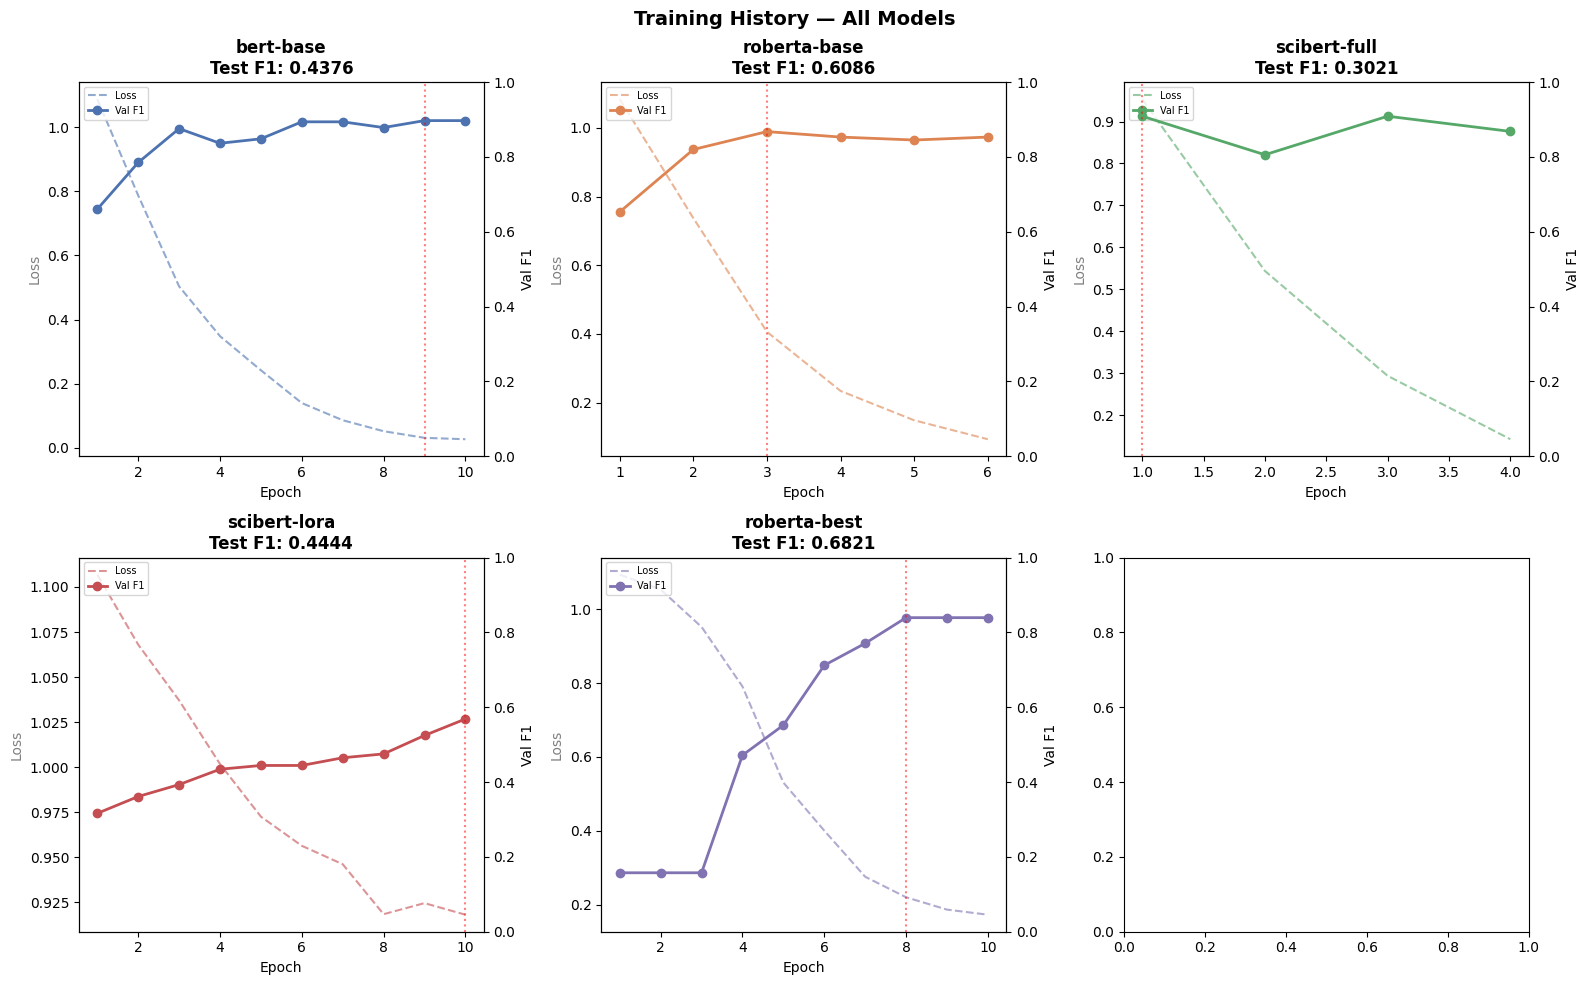

Saved!


In [ ]:
# Cell 12 — Training history plots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']

for i, (name, result) in enumerate(all_results.items()):
    if i >= len(axes): break
    h       = result['history']
    epochs  = [x['epoch']      for x in h]
    losses  = [x['train_loss'] for x in h]
    val_f1s = [x['val_f1']     for x in h]
    ax  = axes[i]
    ax2 = ax.twinx()
    l1, = ax.plot(epochs,  losses,  color=colors[i], linestyle='--', alpha=0.6, label='Train Loss')
    l2, = ax2.plot(epochs, val_f1s, color=colors[i], linewidth=2, marker='o', label='Val F1')
    ax2.axvline(x=epochs[np.argmax(val_f1s)], color='red', linestyle=':', alpha=0.5)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss', color='gray')
    ax2.set_ylabel('Val F1')
    ax2.set_ylim(0, 1)
    ax.set_title(f'{name}\nTest F1: {result["f1_macro"]:.4f}', fontweight='bold')
    ax.legend([l1,l2], ['Loss','Val F1'], loc='upper left', fontsize=7)

plt.suptitle('Training History — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{ANALYSIS_DIR}03_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved!')

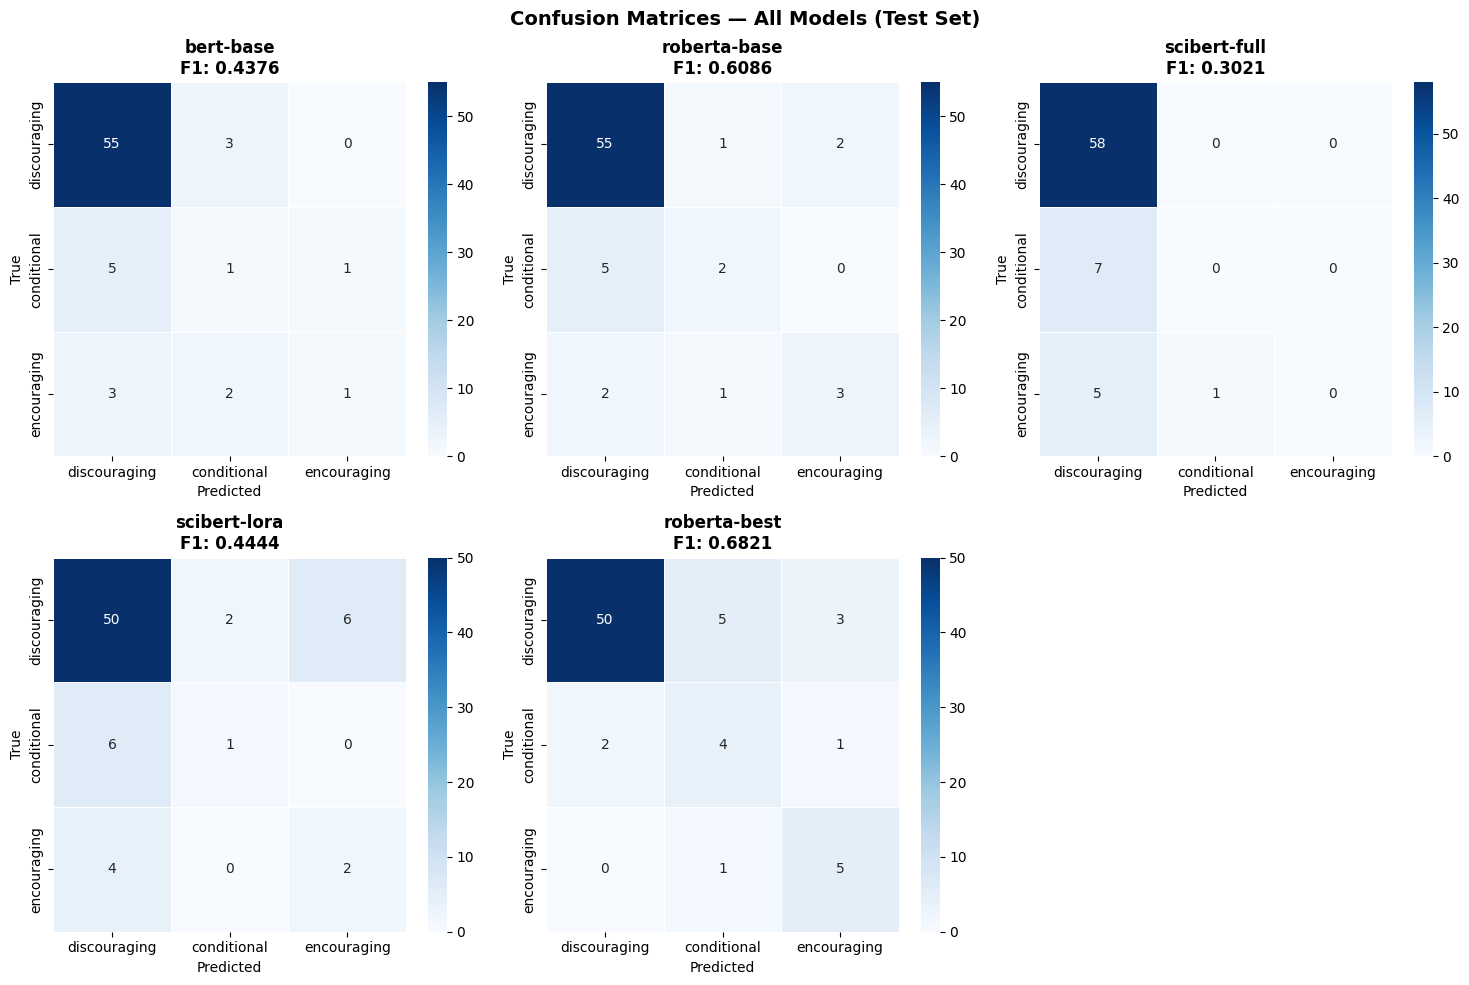

Saved!


In [ ]:
# Cell 13 — Confusion matrices
n_models = len(all_results)
cols_cm  = 3
rows_cm  = (n_models + cols_cm - 1) // cols_cm
fig, axes = plt.subplots(rows_cm, cols_cm, figsize=(15, 5*rows_cm))
axes = axes.flatten()

for i, (name, result) in enumerate(all_results.items()):
    cm = confusion_matrix(result['test_labels'], result['test_preds'], labels=[0,1,2])
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=LABELS, yticklabels=LABELS,
                cmap='Blues', linewidths=0.5, ax=axes[i])
    axes[i].set_title(f'{name}\nF1: {result["f1_macro"]:.4f}', fontweight='bold')
    axes[i].set_ylabel('True')
    axes[i].set_xlabel('Predicted')

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices — All Models (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{ANALYSIS_DIR}03_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved!')

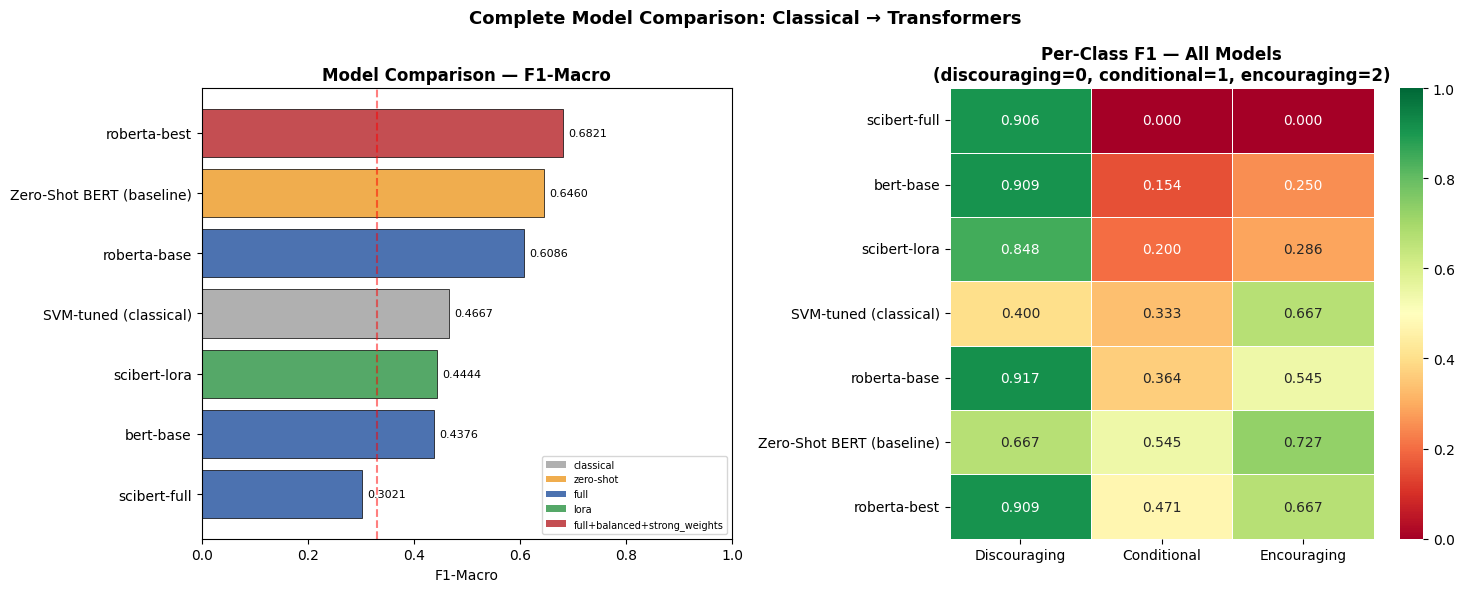

Saved!


In [ ]:
# Cell 14 — Final comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
from matplotlib.patches import Patch

plot_df = full_df.sort_values('f1_macro')
strategy_colors = {
    'classical'              : '#b0b0b0',
    'zero-shot'              : '#f0ad4e',
    'full'                   : '#4C72B0',
    'lora'                   : '#55A868',
    'full+balanced+strong_weights': '#C44E52'
}
bar_colors = [strategy_colors.get(s, '#888') for s in plot_df['strategy']]

bars = axes[0].barh(plot_df['config_name'], plot_df['f1_macro'],
                     color=bar_colors, edgecolor='black', linewidth=0.5)
axes[0].axvline(x=0.33, color='red', linestyle='--', alpha=0.5, label='Random baseline')
axes[0].set_xlabel('F1-Macro')
axes[0].set_title('Model Comparison — F1-Macro', fontweight='bold')
axes[0].set_xlim(0, 1.0)
for bar, val in zip(bars, plot_df['f1_macro']):
    axes[0].text(val+0.01, bar.get_y()+bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=8)
legend_el = [Patch(facecolor=v, label=k) for k,v in strategy_colors.items()]
axes[0].legend(handles=legend_el, loc='lower right', fontsize=7)

hm = plot_df[['config_name','f1_discouraging','f1_conditional','f1_encouraging']].set_index('config_name')
hm.columns = ['Discouraging','Conditional','Encouraging']
sns.heatmap(hm, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.5, ax=axes[1])
axes[1].set_title('Per-Class F1 — All Models\n(discouraging=0, conditional=1, encouraging=2)', fontweight='bold')
axes[1].set_ylabel('')

plt.suptitle('Complete Model Comparison: Classical → Transformers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{ANALYSIS_DIR}03_complete_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved!')

In [ ]:
# Cell 15 — Save all results and print summary
pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['history','test_preds','test_labels']}
    for r in all_results.values()
]).to_csv(f'{RESULTS_DIR}03_transformer_results.csv', index=False)

with open(f'{RESULTS_DIR}03_training_histories.json', 'w') as f:
    json.dump({n: r['history'] for n,r in all_results.items()}, f, indent=2)

best = full_df.iloc[0]
print('='*60)
print('  NOTEBOOK 03 COMPLETE')
print('='*60)
print(f'Label encoding used   : discouraging=0, conditional=1, encouraging=2')
print(f'Best model            : {best["config_name"]}')
print(f'Best F1-Macro         : {best["f1_macro"]}')
print(f'Best Discouraging F1  : {best["f1_discouraging"]}')
print(f'Best Conditional F1   : {best["f1_conditional"]}')
print(f'Best Encouraging F1   : {best["f1_encouraging"]}')
print()
print('Baselines:')
print('  Zero-Shot BERT      : 0.6460')
print('  SVM tuned           : 0.4667')
print(f'  Gap to zero-shot    : {best["f1_macro"] - 0.6460:+.4f}')
print()
print('Next: 04_inter_annotator_agreement.ipynb')
print('='*60)

  NOTEBOOK 03 COMPLETE
Label encoding used   : discouraging=0, conditional=1, encouraging=2
Best model            : roberta-best
Best F1-Macro         : 0.6821
Best Discouraging F1  : 0.9091
Best Conditional F1   : 0.4706
Best Encouraging F1   : 0.6667

Baselines:
  Zero-Shot BERT      : 0.6460
  SVM tuned           : 0.4667
  Gap to zero-shot    : +0.0361

Next: 04_inter_annotator_agreement.ipynb
